# Step 6 : Model Selection for classification

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
filepath = '../Project_btc_sentiment/weekly_btc_2017_2026.csv'
theme_color = ['#36827F','#464D77','#F9DB6D','#F4EDED','#877666'] 

In [3]:
df = pd.read_csv(filepath, index_col= 'Unnamed: 0')
df.index = pd.to_datetime(df.index) 
df.sort_index(ascending = True, inplace=True)

In [4]:
df = df.drop(columns = ['pct_change_1w','pct_change_4w','pct_change_8w'])

In [5]:
df.head(3)

,Sentiment,Open,High,Low,Close,Volume,year,month,quarter,weekno
2017-01-06,0.036157,963.658020,1191.099976,883.943970,902.200989,1762148992,2017,1,1,1
2017-01-13,-0.038909,903.487000,942.723999,755.755981,823.984009,1398173008,2017,1,1,2
2017-01-20,-0.075130,825.142029,917.499023,812.455994,895.026001,819957496,2017,1,1,3


In [6]:
df.index.to_series().rename('date').agg(['min', 'max'])

min   2017-01-06
max   2026-04-17
Name: date, dtype: datetime64[ns]

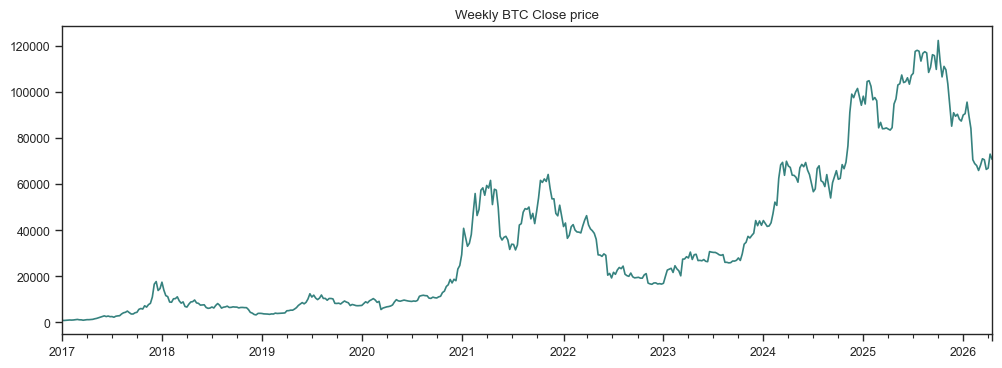

In [7]:
# Visualize the weekly BTC Close price
sns.set_theme(style = 'ticks',context = 'paper')
df['Close'].plot(figsize = (12,4), color = theme_color[0],  title = 'Weekly BTC Close price')
plt.show()

## Target Column Creation

In [8]:
df['r1'] = df['Close'].pct_change(periods = 1)

In [9]:
# QUANTILE method (Balanced Classes) -
upper_threshold = 0.01
lower_threshold = -0.01

mask = (df['r1'] > upper_threshold) | (df['r1'] < lower_threshold) 

print("Kept:", mask.sum())
print("Dropped neutral:", (~mask).sum())
print("Kept %:", mask.mean())

df = df.loc[mask].copy()
df['label_q'] = (df.loc[mask, 'r1'] > upper_threshold).astype(int) # uptrend is 1 , downtrend is 0

Kept: 417
Dropped neutral: 68
Kept %: 0.8597938144329897


In [10]:
# Check Class balance
df['label_q'].value_counts(normalize=True)

label_q
1    0.549161
0    0.450839
Name: proportion, dtype: float64

## Feature Engeeneering

In [11]:
EPS = 1e-8

# Compute r1
df['r1'] = df['Close'].pct_change(1) 

# compute lag r1 
for lag in [2,4,8,12]:
    df[f"r1_lag{lag}"] = df['r1'].shift(lag) 

# Compute lag multi-Horizon return then lag 
for k in [2,4,8,12]:
    df[f"r{k}_lag1"] = df["Close"].pct_change(k).shift(1)

# Compute Volatility/momentum on weekly log returns then lag 
for w in [2,4,8,12]:
    df[f"vol_{w}w_lag1"] = df["r1"].rolling(w).std().shift(1)
    df[f"mom_{w}w_lag1"] = df["r1"].rolling(w).mean().shift(1) 

# compute high-low range 
df["hl_range"] = (df["High"] - df["Low"]) / (df["Close"] + EPS)

for w in [2,4,8,12]:
    df[f"hl_range_mean_{w}_lag1"] = df["hl_range"].rolling(w).mean().shift(1)
    df[f"hl_range_std_{w}_lag1"] = df["hl_range"].rolling(w).std().shift(1) 

# ---- Trend ---
for w in [2,4,8,12]:
    ma = df["Close"].rolling(w).mean()
    df[f"close_to_ma_{w}_lag1"] = ((df["Close"] - ma) / (ma + EPS)).shift(1)
    df[f"ma_slope_{w}_lag1"] = ma.diff().shift(1)

# --- Volume ---
df["dollar_volume_lag1"] = (df["Close"] * df["Volume"]).shift(1)
df["volume_change_1_lag1"] = df["Volume"].pct_change().shift(1)

for w in [2,4,8,12]:
    vol_mu = df["Volume"].rolling(w).mean()
    vol_sd = df["Volume"].rolling(w).std()
    
    df[f"vol_ratio_{w}_lag1"] = (df["Volume"] / (vol_mu + EPS)).shift(1)
    df[f"vol_z_{w}_lag1"] = ((df["Volume"] - vol_mu) / (vol_sd + EPS)).shift(1)

# Define RSI function
def rsi_wilder(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)

    avg_gain = gain.ewm(alpha=1/period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False, min_periods=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

for p in [4,8,12]:
    df[f"RSI_{p}w"] = rsi_wilder(df["Close"], p)
    df[f"RSI_{p}w_lag1"] = df[f"RSI_{p}w"].shift(1)


# sentiment features engineering 
df["sentiment_lag_1"] = df["Sentiment"].shift(1)
df["sentiment_chg_1_lag1"] = df["Sentiment"].diff(1).shift(1)
df["sentiment_chg_2_lag1"] = df["Sentiment"].diff(2).shift(1) 

# rolling sentiment 
for w in [4,8]:
    df[f"s_mean_{w}_lag1"] = df["Sentiment"].rolling(w).mean().shift(1)
    df[f"s_std_{w}_lag1"]  = df["Sentiment"].rolling(w).std().shift(1) 

# extreme sentiment features 
z = (df["Sentiment"] - df["Sentiment"].rolling(8).mean()) / df["Sentiment"].rolling(8).std()
df["sentiment_z8_lag1"] = z.shift(1)

# x momentum features 
df['sentiment_x_momentum_lag1'] = df['sentiment_lag_1'] * df['mom_4w_lag1']
df['rsi_x_sentiment_lag1'] = df['RSI_4w_lag1'] *df['sentiment_lag_1'] 
df['sentiment_x_trend_lag1'] = df['sentiment_lag_1'] * df['close_to_ma_4_lag1']

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 417 entries, 2017-01-13 to 2026-04-17
Data columns (total 72 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sentiment                  417 non-null    float64
 1   Open                       417 non-null    float64
 2   High                       417 non-null    float64
 3   Low                        417 non-null    float64
 4   Close                      417 non-null    float64
 5   Volume                     417 non-null    int64  
 6   year                       417 non-null    int64  
 7   month                      417 non-null    int64  
 8   quarter                    417 non-null    int64  
 9   weekno                     417 non-null    int64  
 10  r1                         416 non-null    float64
 11  label_q                    417 non-null    int64  
 12  r1_lag2                    414 non-null    float64
 13  r1_lag4                    412 

## Visualize Target Distribution

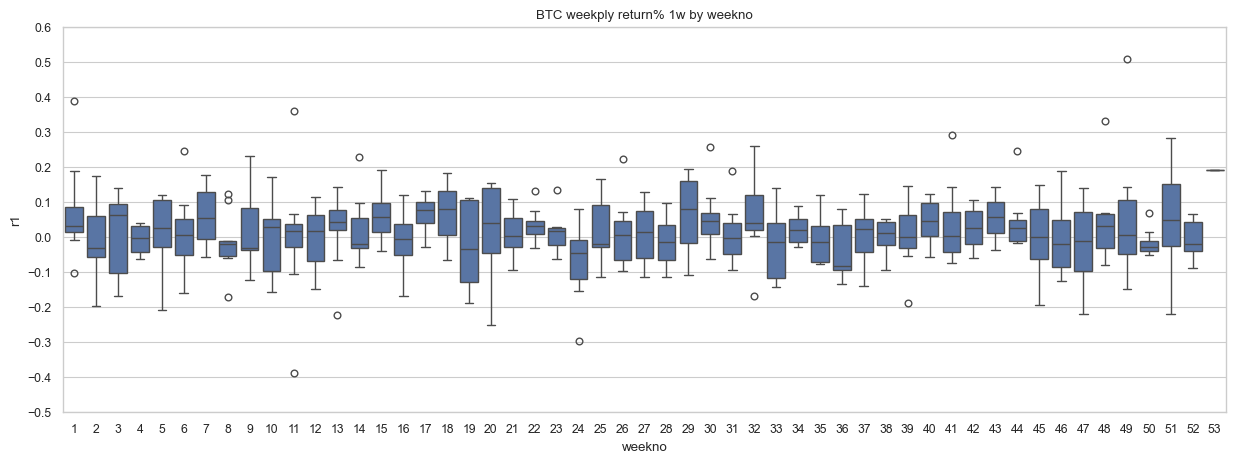

In [13]:
sns.set_theme(style = 'whitegrid',context = 'paper')
plt.figure(figsize = (15,5)) 
sns.boxplot(data = df , x = 'weekno', y = 'r1')
plt.yticks(np.linspace(-0.5, 0.6, 12))
plt.title('BTC weekply return% 1w by weekno')
plt.show()

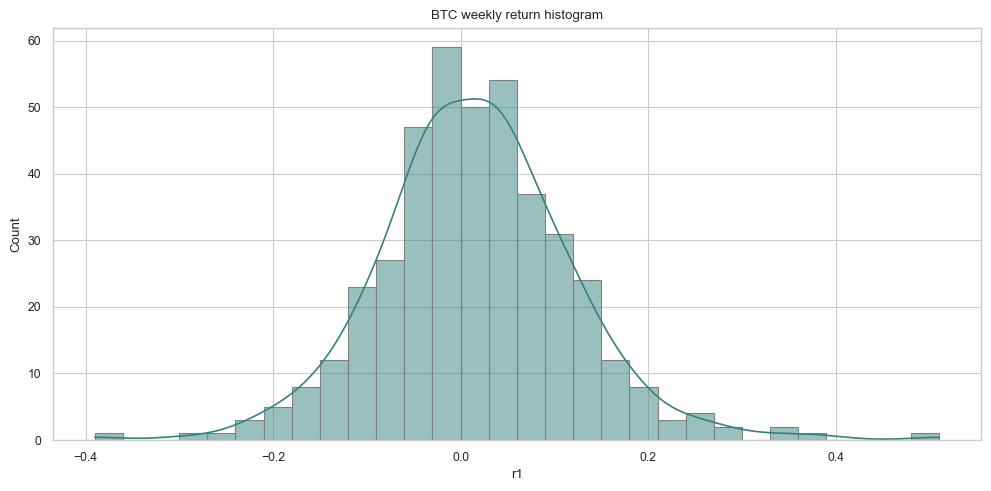

In [14]:
plt.figure(figsize = (10,5)) 
sns.histplot(x=df['r1'], edgecolor = 'grey', color = theme_color[0], alpha=0.5, kde=True) 
plt.title('BTC weekly return histogram')
plt.tight_layout() 
plt.show()

### Testing for Tree Models

In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (classification_report, confusion_matrix,roc_curve, accuracy_score, 
                            roc_auc_score, auc, f1_score, balanced_accuracy_score) 

from xgboost import XGBClassifier , XGBRFClassifier

In [16]:
# --- 1) Define columns set for different scenario ---
price_cols = [    
    # --- Returns / momentum ---
    'r1_lag2',
    'r1_lag8',
    'r1_lag12',
    'r4_lag1',

    # --- Volatility ---
    'vol_4w_lag1',
    'mom_4w_lag1',
    'vol_12w_lag1',
    'mom_12w_lag1',
    'hl_range_std_4_lag1',
    'hl_range_std_12_lag1',

    # --- Trend ---
    'close_to_ma_4_lag1',
    'ma_slope_4_lag1',
    'close_to_ma_8_lag1',
    'ma_slope_8_lag1',
    
    # --- Volume ---
    'dollar_volume_lag1',
    'volume_change_1_lag1',
    'vol_z_4_lag1',
    'vol_z_8_lag1',
    'vol_z_12_lag1',
    
    # --- RSI ---
    'RSI_4w_lag1',
    'RSI_8w_lag1',
    'RSI_12w_lag1',

] 

sent_cols = [
     # --- Sentiment ---
    'sentiment_lag_1',
    'sentiment_chg_1_lag1',
    'sentiment_chg_2_lag1',
    's_mean_4_lag1',
    's_std_4_lag1',
    's_mean_8_lag1',
    's_std_8_lag1',
    'sentiment_z8_lag1',
    'sentiment_x_momentum_lag1',
    'rsi_x_sentiment_lag1',
    'sentiment_x_trend_lag1'  
]

X_sets = {
    "price_only": price_cols,
    "sent_only": sent_cols,
    "combined": price_cols + sent_cols,      
} 

In [17]:
# --- 2) Prepare data ---
df_model = df.copy().sort_index()   # or sort_values("date") if you have a date column
df_model = df_model.dropna(subset=price_cols + sent_cols + ["label_q"])  # simplest

# target value, y
y = df_model["label_q"].astype(int) 

# --- 3) TimeSeriesSplit (walk-forward) ---
tscv = TimeSeriesSplit(n_splits=5)  # consider test_size / gap later

# --- 4) Models ---
# Dummy baselines (must-have)
dummy_mf = DummyClassifier(strategy="most_frequent")   # majority class baseline
dummy_strat = DummyClassifier(strategy="stratified", random_state=42)

# Real baselines
logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])



rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2
    ))
])

hgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", HistGradientBoostingClassifier(
        random_state=42,
        max_depth=3,
        learning_rate=0.05
    ))
])


xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        objective="binary:logistic",   # because label_q has 3 classes             
        max_depth=3,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="auc",
        tree_method="hist"
    ))
])



xgbrf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", XGBRFClassifier(
        objective ="binary:logistic",   # 3-class probability output
        # --- RF-specific settings ---
        n_estimators=500,             # more trees is typical for RF
        max_depth=5,                  # RF benefits from slightly deeper trees
        subsample=0.8,                # row sampling
        colsample_bynode=0.8,         # IMPORTANT: RF-style feature sampling
        # --- regularization ---
        reg_lambda=1.0,
        # --- misc ---
        random_state=42,
        eval_metric="auc",
        tree_method="hist"
    ))
])


models = {
    "dummy_mostfreq": (dummy_mf, y),
    "dummy_stratified": (dummy_strat, y),
    "logreg": (logreg, y),
    "random_forest": (rf, y),
    "hist_gb": (hgb, y),
    "xgboost": (xgb, y),   # <- only this uses y_xgb 
    "xgboost_rf" : (xgbrf, y),
}

In [18]:
# --- 5) Evaluation loop ---
def run_backtest(X, y, model, cv):
    f1s, bals = [], []
    cms = []
    for fold, (tr, te) in enumerate(cv.split(X), 1):
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)

        f1s.append(f1_score(y_te, pred, average="macro"))
        bals.append(balanced_accuracy_score(y_te, pred))
        cms.append(confusion_matrix(y_te, pred, labels=[-1, 0, 1]))

    return {
        "macro_f1_mean": float(np.mean(f1s)),
        "macro_f1_std": float(np.std(f1s)),
        "bal_acc_mean": float(np.mean(bals)),
        "bal_acc_std": float(np.std(bals)),
        "conf_matrices": cms,
    }

In [19]:
results = {}

for set_name, cols in X_sets.items():
    X = df_model[cols]
    results[set_name] = {}
    
    for model_name, (model,y_used) in models.items():
        results[set_name][model_name] = run_backtest(X, y_used, model, tscv)

# --- 6) Display summary ---
summary_rows = []
for set_name in results:
    for model_name in results[set_name]:
        r = results[set_name][model_name]
        summary_rows.append({
            "feature_set": set_name,
            "model": model_name,
            "macro_f1_mean": r["macro_f1_mean"],
            "bal_acc_mean": r["bal_acc_mean"],
        })

summary = pd.DataFrame(summary_rows).sort_values(["feature_set","macro_f1_mean"], ascending=[True, False])
summary

,feature_set,model,macro_f1_mean,bal_acc_mean
19,combined,xgboost,0.500251,0.523752
18,combined,hist_gb,0.495863,0.516014
17,combined,random_forest,0.492950,0.512544
15,combined,dummy_stratified,0.490579,0.499968
20,combined,xgboost_rf,0.488820,0.508304
16,combined,logreg,0.472037,0.522646
14,combined,dummy_mostfreq,0.344810,0.500000
1,price_only,dummy_stratified,0.490579,0.499968
4,price_only,hist_gb,0.471415,0.482556
6,price_only,xgboost_rf,0.466100,0.479933


In [20]:
print(f'Combining sentiment with price information yields the strongest and most stable performance,')
print(f'suggesting that news sentiment provides complementary information beyond historical price dynamics.')

Combining sentiment with price information yields the strongest and most stable performance,
suggesting that news sentiment provides complementary information beyond historical price dynamics.
